In [1]:
import os
import math
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import pylab

import plant_gravitropism as pg

In [2]:
OUTDIR = "paper-figs/Gravitropism-Pareto-Front"
os.makedirs(OUTDIR, exist_ok=True)

In [3]:
def get_observed_lateral_segments(arbor):
    segments = []
    tips = [n for n in arbor.nodes if arbor.nodes[n]["label"] == "lateral root tip"]

    for tip in tips:
        curr = tip
        prev = None
        while True:
            neighbors = list(arbor.neighbors(curr))
            if prev is not None:
                neighbors = [n for n in neighbors if n != prev]

            if len(neighbors) == 0:
                break

            next_node = neighbors[0]
            segments.append((curr, next_node))
            prev, curr = curr, next_node

            if arbor.nodes[curr]["label"].startswith("main root"):
                break

    return segments

In [4]:
def draw_main_root(fig, arbor, color="black", width=4):
    segments = pg.get_main_root_segments(arbor)
    for (x0, y0), (x1, y1) in segments:
        fig.add_trace(go.Scatter(
            x=[x0, x1], y=[y0, y1],
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False
        ))

def draw_lateral_roots(fig, arbor, color="green", width=2):
    segments = get_observed_lateral_segments(arbor)
    for (x0, y0), (x1, y1) in segments:
        fig.add_trace(go.Scatter(
            x=[x0, x1], y=[y0, y1],
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False
        ))

def draw_tips(fig, arbor, color="orange"):
    tips = [n for n in arbor.nodes if arbor.nodes[n]["label"] == "lateral root tip"]
    for tip in tips:
        fig.add_trace(go.Scatter(
            x=[tip[0]], y=[tip[1]],
            mode="markers",
            marker=dict(color=color, size=6),
            showlegend=False
        ))

In [5]:
def draw_optimized_curves(fig, arbor, G, alpha, color):
    results = pg.arbor_best_cost(arbor, G, alpha)

    for result in results:
        x0, y0 = result[4], result[5]
        p, q = result[6], result[7]

        if G == 0:
            xs, ys = [p, x0], [q, y0]
        else:
            b, c = pg.calc_coeff(G, x0, y0, p, q)
            xs = np.linspace(min(p, x0), max(p, x0), 100)
            ys = G * xs**2 + b * xs + c

        fig.add_trace(go.Scatter(
            x=xs,
            y=ys,
            mode="lines",
            line=dict(color=color, width=2),
            showlegend=False
        ))

In [12]:
def create_base_figure(arbor):
    fig = go.Figure()

    draw_main_root(fig, arbor)
    draw_lateral_roots(fig, arbor)
    draw_tips(fig, arbor)

    base = arbor.graph['main root base']
    fig.add_trace(go.Scatter(
        x=[base[0]], y=[base[1]],
        mode="markers",
        marker=dict(color="purple", size=30),
        showlegend=False
    ))

    fig.update_layout(
        xaxis_title="",
        yaxis_title="",
        yaxis_autorange="reversed",
        width=800,
        height=700,
        showlegend=False,
        margin=dict(t=20, b=20)
    )
    
    fig.update_layout(title=None)

    return fig

In [13]:
def G_to_color(G, Gmin=-2, Gmax=2):
    norm = (G - Gmin) / (Gmax - Gmin)
    return f"rgba({int(255*norm)}, 0, {int(255*(1-norm))}, 1)"

In [14]:
def alpha_to_color(alpha, alpha_min=0, alpha_max=1):
    norm = (alpha - alpha_min) / (alpha_max - alpha_min)
    return f"rgba({int(255*norm)}, 0, {int(255*(1-norm))}, 1)"

In [42]:
def panel_vary_alpha(fname, G, alphas, save_name):
    arbor = pg.rar.read_arbor_full(fname)
    fig = create_base_figure(arbor)

    for alpha in alphas:
        color = alpha_to_color(alpha)
        draw_optimized_curves(fig, arbor, G, alpha, color)
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode="lines",
            line=dict(color=color, width=3),
            name=f"alpha = {alpha}"
        ))
        
    fig.update_layout(showlegend=True, legend=dict(font=dict(size=25)))
    
    fig.update_xaxes(showticklabels=False)
    fig.update_yaxes(showticklabels=False)

    outpath = f"{OUTDIR}/{save_name}.pdf"
    fig.show()
    fig.write_image(outpath)
    print("Saved:", outpath)

In [43]:
def panel_vary_G(fname, alpha, G_values, save_name):
    arbor = pg.rar.read_arbor_full(fname)
    fig = create_base_figure(arbor)

    for G in G_values:
        color = G_to_color(G)
        draw_optimized_curves(fig, arbor, G, alpha, color)
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode="lines",
            line=dict(color=color, width=3),
            name=f"G = {G}"
        ))
    
    fig.update_layout(showlegend=True, legend=dict(font=dict(size=25)))
    
    fig.update_xaxes(showticklabels=False)
    fig.update_yaxes(showticklabels=False)

    outpath = f"{OUTDIR}/{save_name}.pdf"
    fig.show()
    fig.write_image(outpath)
    print("Saved:", outpath)

In [44]:
def plot_pareto_front(fname, save_name="pareto.pdf"):

    path = f"data/results/gravitropism_pareto_fronts/{fname}"
    df = pd.read_csv(path, skipinitialspace=True)

    fig = go.Figure()

    # Observed point
    df_obs = df[df['arbor type'] == 'observed']
    fig.add_trace(go.Scatter(
        x=df_obs['wiring cost'],
        y=df_obs['conduction delay'],
        mode='markers',
        marker=dict(size=30, color='green'),
        name='Observed'
    ))

    # Optimized grouped by G
    df_opt = df[df['arbor type'] == 'optimal']
    allowed_G = pylab.arange(0, 5, 0.5)
    df_opt = df_opt[df_opt["G"].isin(allowed_G)]
    unique_G = sorted(df_opt['G'].unique())

    colors = np.linspace(0, 1, len(unique_G))

    for i, G in enumerate(unique_G):
        sub = df_opt[df_opt['G'] == G].sort_values('alpha')

        fig.add_trace(go.Scatter(
            x=sub['wiring cost'],
            y=sub['conduction delay'],
            mode='lines+markers',
            line=dict(
                color=f"rgba({int(255*colors[i])}, 0, {int(255*(1-colors[i]))}, 1)",
                width=3
            ),
            marker=dict(size=6),
            name=f"G = {G}"
        ))

    fig.update_layout(
        xaxis_title="Wiring Cost",
        yaxis_title="Conduction Delay",
        width=700,
        height=600,
        legend=dict(font=dict(size=18))
    )
    
    fig.update_layout(
        title=None,
        margin=dict(t=20, b=20)
    )
    
    fig.update_layout(
        font=dict(size=30),  # base
        xaxis_title_font=dict(size=30),
        yaxis_title_font=dict(size=30),
        xaxis_tickfont=dict(size=25),
        yaxis_tickfont=dict(size=25),
    )


    outpath = f"{OUTDIR}/{save_name}.pdf"
    fig.show()
    fig.write_image(outpath)

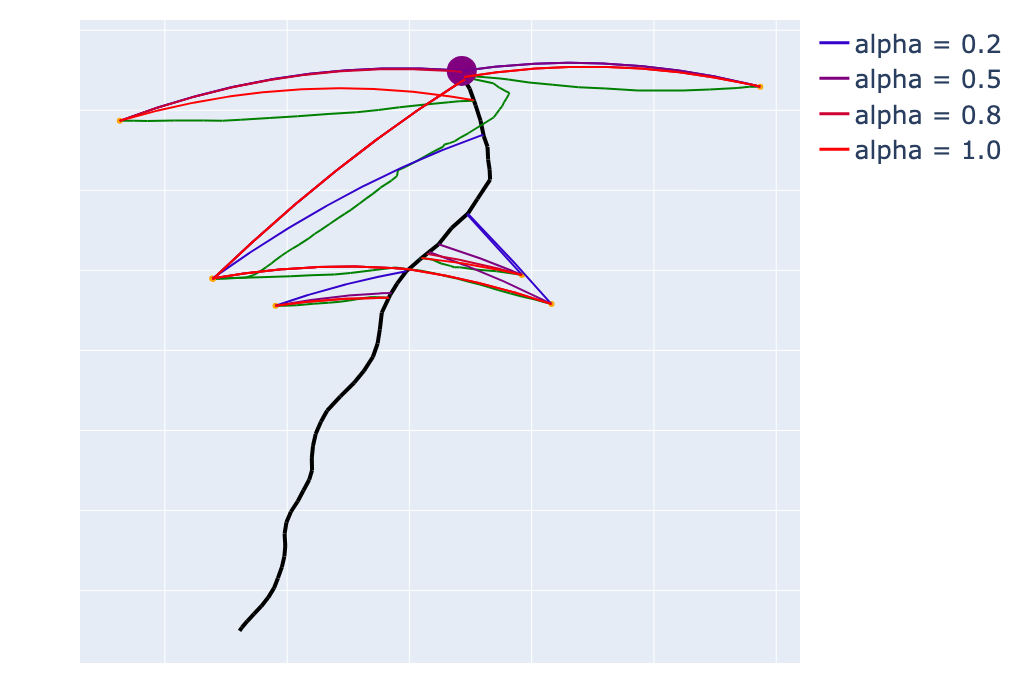

Saved: paper-figs/Gravitropism-Pareto-Front/panel_alpha.pdf


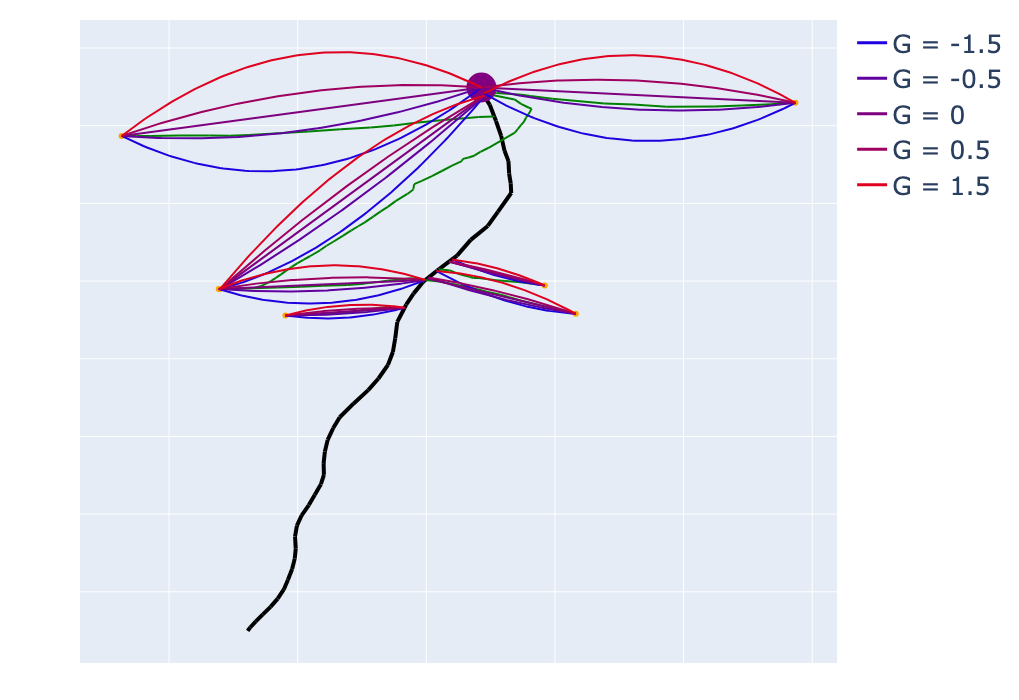

Saved: paper-figs/Gravitropism-Pareto-Front/panel_G.pdf


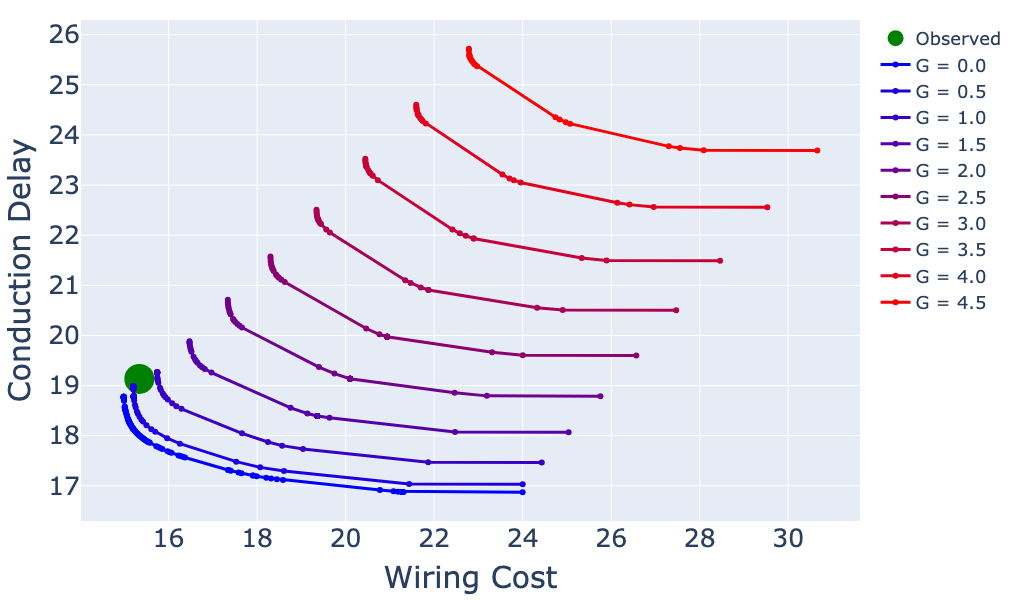

In [45]:
fname = "pimpi_Big5_all_day_set1_day4_20191023_025_112_4_S.csv"

# Panel A: fix G, vary alpha
panel_vary_alpha(
    fname,
    G=0.5,
    alphas=[0.2, 0.5, 0.8, 1.0],
    save_name="panel_alpha"
)

# Panel B: fix alpha, vary G
panel_vary_G(
    fname,
    alpha=0.7,
    G_values=[-1.5, -0.5, 0, 0.5, 1.5],
    save_name="panel_G"
)

# Panel C: Pareto front
plot_pareto_front(
    fname,
    save_name="panel_pareto"
)